# User Purchase Prediction - Exploratory Data Analysis (EDA)

## Dataset Overview

- **Training Data**: Purchase data of users in Part A (6,989,817 records, 483,117 buyers)

- **Product Attribute Table**: Category ID, store ID, encrypted price, and other information for 1,873,173 products

## Data Characteristics

- Each user has at least 7 purchase records.

- The product corresponding to the last purchase record of each user in the test data must have appeared in the training data.

- The intersection of the user sets in the training and test data is empty.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

In [2]:
train_df = pd.read_csv('data/Antai_hackathon_train.csv')
item_attr_df = pd.read_csv('data/Antai_hackathon_attr.csv')

print(f'Training data shape:{train_df.shape}')
print(f'Product attribute table shape:{item_attr_df.shape}')

Training data shape:(6989817, 5)
Product attribute table shape:(1924269, 4)


## Data Description

In [3]:
print('Training data')
display(train_df.head())

print('\nTraining data info')
train_df.info()

print('\nTraining data description')
display(train_df.describe())

Training data


,buyer_country_id,buyer_admin_id,item_id,create_order_time,irank
0,xx,489859,1,2018-04-11 03:28:02,9
1,xx,2567786,2,2018-04-14 08:24:26,26
2,xx,3408746,3,2018-04-17 02:11:56,7
3,xx,2801580,4,2018-04-20 10:11:17,3
4,xx,1348149,5,2018-04-17 10:49:05,4



Training data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6989817 entries, 0 to 6989816
Data columns (total 5 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   buyer_country_id   object
 1   buyer_admin_id     int64 
 2   item_id            int64 
 3   create_order_time  object
 4   irank              int64 
dtypes: int64(3), object(2)
memory usage: 266.6+ MB

Training data description


,buyer_admin_id,item_id,irank
count,6.989817e+06,6.989817e+06,6.989817e+06
mean,3.793427e+06,3.792787e+06,2.932768e+01
std,2.190327e+06,2.189486e+06,3.023179e+02
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.896300e+06,1.896413e+06,4.000000e+00
50%,3.795519e+06,3.793176e+06,8.000000e+00
75%,5.689123e+06,5.689069e+06,1.300000e+01
max,7.585728e+06,7.585750e+06,1.176600e+04


In [4]:
print('Item attribute table')
display(item_attr_df.head())

print('\nItem attribute table info')
item_attr_df.info()

print('\nItem attribute table description')
display(item_attr_df.describe())

Item attribute table


,item_id,cate_id,store_id,item_price
0,140446,1413,11822,1
1,403593,2313,19712,1
2,252621,1682,6622,1
3,204530,1413,11822,1
4,340076,181,24403,1



Item attribute table info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1924269 entries, 0 to 1924268
Data columns (total 4 columns):
 #   Column      Dtype
---  ------      -----
 0   item_id     int64
 1   cate_id     int64
 2   store_id    int64
 3   item_price  int64
dtypes: int64(4)
memory usage: 58.7 MB

Item attribute table description


,item_id,cate_id,store_id,item_price
count,1.924269e+06,1.924269e+06,1.924269e+06,1.924269e+06
mean,3.882977e+06,1.380070e+03,3.368103e+04,1.038872e+03
std,2.184653e+06,8.623223e+02,1.985649e+04,1.773790e+03
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,2.006722e+06,5.840000e+02,1.710700e+04,1.770000e+02
50%,3.926939e+06,1.416000e+03,3.282500e+04,4.130000e+02
75%,5.777812e+06,1.913000e+03,4.939000e+04,1.151000e+03
max,7.585751e+06,3.902000e+03,7.818600e+04,1.620100e+04


In [5]:
print('User purchase behavior statistics')
train_user_stats = train_df.groupby('buyer_admin_id').agg({
    'item_id': 'count',
    'irank': ['min', 'max'],
    'create_order_time': ['min', 'max']
}).round(2)
train_user_stats.columns = ['Number of purchases', 'Minimum irank', 'Maximum irank', 'First purchase time', 'Last purchase time']
display(train_user_stats.describe())

print(f'\nNumber of unique buyers in training data:{train_df["buyer_admin_id"].nunique()}')
print(f'Total number of training data records:{len(train_df)}')
print(f'Average number of purchases per person:{len(train_df) / train_df["buyer_admin_id"].nunique():.2f}')

User purchase behavior statistics


,Number of purchases,Minimum irank,Maximum irank
count,483117.000000,483117.0,483117.000000
mean,14.468166,1.0,14.468166
std,24.996817,0.0,24.996817
min,8.000000,1.0,8.000000
25%,9.000000,1.0,9.000000
50%,11.000000,1.0,11.000000
75%,15.000000,1.0,15.000000
max,11766.000000,1.0,11766.000000



Number of unique buyers in training data:483117
Total number of training data records:6989817
Average number of purchases per person:14.47


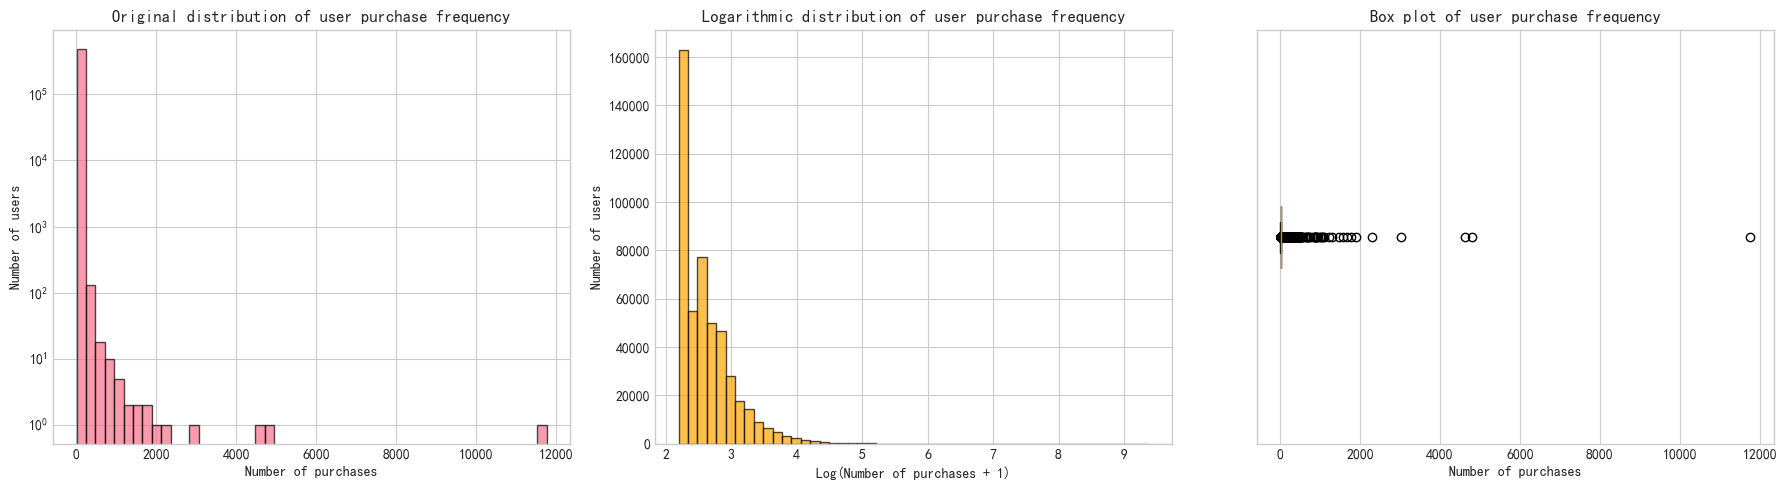


User purchase frequency statistics:
Average:14.47
Median:11.00
Standard deviation:25.00
Minimum value:8
Maximum value:11766
Skewness:254.37
Kuroshi:107169.24


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_purchase_counts = train_df.groupby('buyer_admin_id').size()
axes[0].hist(train_purchase_counts, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Original distribution of user purchase frequency')
axes[0].set_xlabel('Number of purchases')
axes[0].set_ylabel('Number of users')
axes[0].set_yscale('log')

log_purchase_counts = np.log1p(train_purchase_counts)
axes[1].hist(log_purchase_counts, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Logarithmic distribution of user purchase frequency')
axes[1].set_xlabel('Log(Number of purchases + 1)')
axes[1].set_ylabel('Number of users')

axes[2].boxplot(train_purchase_counts.values, vert=False, patch_artist=True)
axes[2].set_title('Box plot of user purchase frequency')
axes[2].set_xlabel('Number of purchases')
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

print(f'\nUser purchase frequency statistics:')
print(f'Average:{train_purchase_counts.mean():.2f}')
print(f'Median:{train_purchase_counts.median():.2f}')
print(f'Standard deviation:{train_purchase_counts.std():.2f}')
print(f'Minimum value:{train_purchase_counts.min()}')
print(f'Maximum value:{train_purchase_counts.max()}')
print(f'Skewness:{train_purchase_counts.skew():.2f}')
print(f'Kuroshi:{train_purchase_counts.kurtosis():.2f}')


 Long-tail distribution threshold and coverage analysis



,threshold,Number of high-frequency users,User Coverage (%),Order Coverage Rate (%),Number of orders per person
0,5,483117,100.00,100.00,14.47
1,10,320251,66.29,80.35,17.54
2,15,137999,28.56,50.21,25.43
3,20,71252,14.75,34.31,33.66
4,30,26117,5.41,19.20,51.40
5,50,7278,1.51,9.36,89.85
6,100,1435,0.30,3.93,191.57


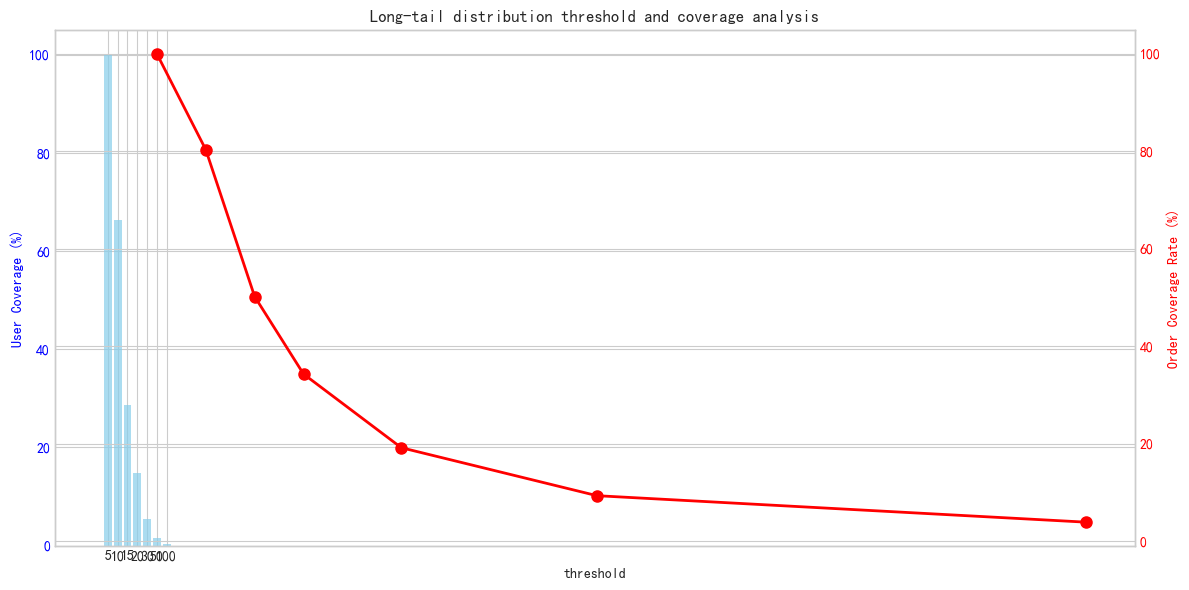


Analysis of the Pareto Principle:
Top 65.78% users account for 80% of the orders.
Order percentage of the top 20% of users:40.90%


In [7]:
print('\n Long-tail distribution threshold and coverage analysis\n')

thresholds = [5, 10, 15, 20, 30, 50, 100]
total_users = len(train_purchase_counts)
total_purchases = train_purchase_counts.sum()

coverage_data = []
for threshold in thresholds:
    high_freq_users = train_purchase_counts[train_purchase_counts >= threshold]
    high_freq_count = len(high_freq_users)
    high_freq_purchases = high_freq_users.sum()
    
    user_coverage = (high_freq_count / total_users) * 100
    purchase_coverage = (high_freq_purchases / total_purchases) * 100
    
    coverage_data.append({
        'threshold': threshold,
        'Number of high-frequency users': high_freq_count,
        'User Coverage (%)': round(user_coverage, 2),
        'Order Coverage Rate (%)': round(purchase_coverage, 2),
        'Number of orders per person': round(high_freq_purchases / high_freq_count, 2)
    })

coverage_df = pd.DataFrame(coverage_data)
display(coverage_df)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(coverage_df['threshold'].astype(str), coverage_df['User Coverage (%)'], 
        alpha=0.7, color='skyblue', label='User Coverage')
ax1.set_xlabel('threshold')
ax1.set_ylabel('User Coverage (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Long-tail distribution threshold and coverage analysis')

ax2 = ax1.twinx()
ax2.plot(coverage_df['threshold'], coverage_df['Order Coverage Rate (%)'], 
         color='red', marker='o', linewidth=2, markersize=8, label='Order Coverage Rate')
ax2.set_ylabel('Order Coverage Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.tight_layout()
plt.show()

sorted_counts = train_purchase_counts.sort_values(ascending=False)
cumulative_sum = sorted_counts.cumsum()
total_sum = sorted_counts.sum()

threshold_80 = cumulative_sum[cumulative_sum >= 0.8 * total_sum].index[0]
top_users_ratio = (sorted_counts.index.get_loc(threshold_80) + 1) / len(sorted_counts) * 100

print(f'\nAnalysis of the Pareto Principle:')
print(f'Top {top_users_ratio:.2f}% users account for 80% of the orders.')
print(f'Order percentage of the top 20% of users:{(sorted_counts.head(int(len(sorted_counts)*0.2)).sum() / total_sum * 100):.2f}%')


User purchase time interval analysis



,First purchase time,Last purchase time,Purchase interval days,Active days
count,483117,483117,483117.000000,483117.000000
mean,2018-04-08 21:54:47.054568448,2018-04-21 14:18:30.145198848,12.253241,13.253241
min,2018-03-13 04:01:00,2018-03-17 11:13:41,0.000000,1.000000
25%,2018-04-03 14:43:13,2018-04-18 01:50:39,4.000000,5.000000
50%,2018-04-06 23:07:17,2018-04-23 13:15:32,13.000000,14.000000
75%,2018-04-12 12:18:40,2018-04-26 22:38:55,20.000000,21.000000
max,2018-04-28 23:58:04,2018-04-28 23:59:57,45.000000,46.000000
std,NaN,NaN,8.438550,8.438550



Average purchase interval:12.25 days
Median purchase interval:13.00 days
Longest purchase interval:45 days
Shortest purchase interval:0 days


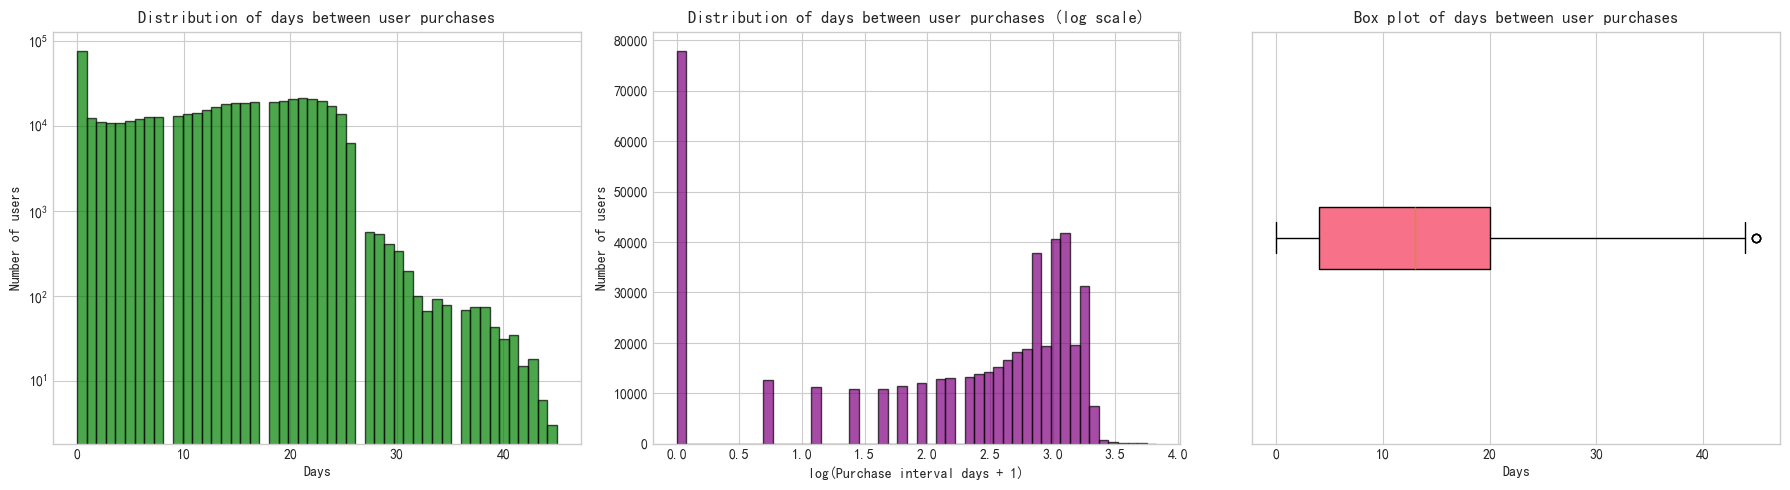

In [8]:
print('\nUser purchase time interval analysis\n')

if train_df['create_order_time'].dtype == 'object':
    train_df['create_order_time'] = pd.to_datetime(train_df['create_order_time'])

user_time_stats = train_df.groupby('buyer_admin_id')['create_order_time'].agg(['min', 'max'])
user_time_stats.columns = ['First purchase time', 'Last purchase time']


user_time_stats['Purchase interval days'] = (user_time_stats['Last purchase time'] - user_time_stats['First purchase time']).dt.days
user_time_stats['Active days'] = user_time_stats['Purchase interval days'] + 1

display(user_time_stats.describe())

print(f'\nAverage purchase interval:{user_time_stats["Purchase interval days"].mean():.2f} days')
print(f'Median purchase interval:{user_time_stats["Purchase interval days"].median():.2f} days')
print(f'Longest purchase interval:{user_time_stats["Purchase interval days"].max()} days')
print(f'Shortest purchase interval:{user_time_stats["Purchase interval days"].min()} days')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(user_time_stats['Purchase interval days'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].set_title('Distribution of days between user purchases')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of users')
axes[0].set_yscale('log')

log_interval = np.log1p(user_time_stats['Purchase interval days'])
axes[1].hist(log_interval, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1].set_title('Distribution of days between user purchases (log scale)')
axes[1].set_xlabel('log(Purchase interval days + 1)')
axes[1].set_ylabel('Number of users')

axes[2].boxplot(user_time_stats['Purchase interval days'].values, vert=False, patch_artist=True)
axes[2].set_title('Box plot of days between user purchases')
axes[2].set_xlabel('Days')
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

In [9]:
print('Training data product statistics')
print(f'Number of unique items:{train_df["item_id"].nunique()}')
print(f'Total number of records:{len(train_df)}')
print(f'Average number of purchases per item:{len(train_df) / train_df["item_id"].nunique():.2f}')

print('\nProduct Attribute Table Product Statistics')
print(f'Number of unique items:{item_attr_df["item_id"].nunique()}')

Training data product statistics
Number of unique items:1852506
Total number of records:6989817
Average number of purchases per item:3.77

Product Attribute Table Product Statistics
Number of unique items:1924269


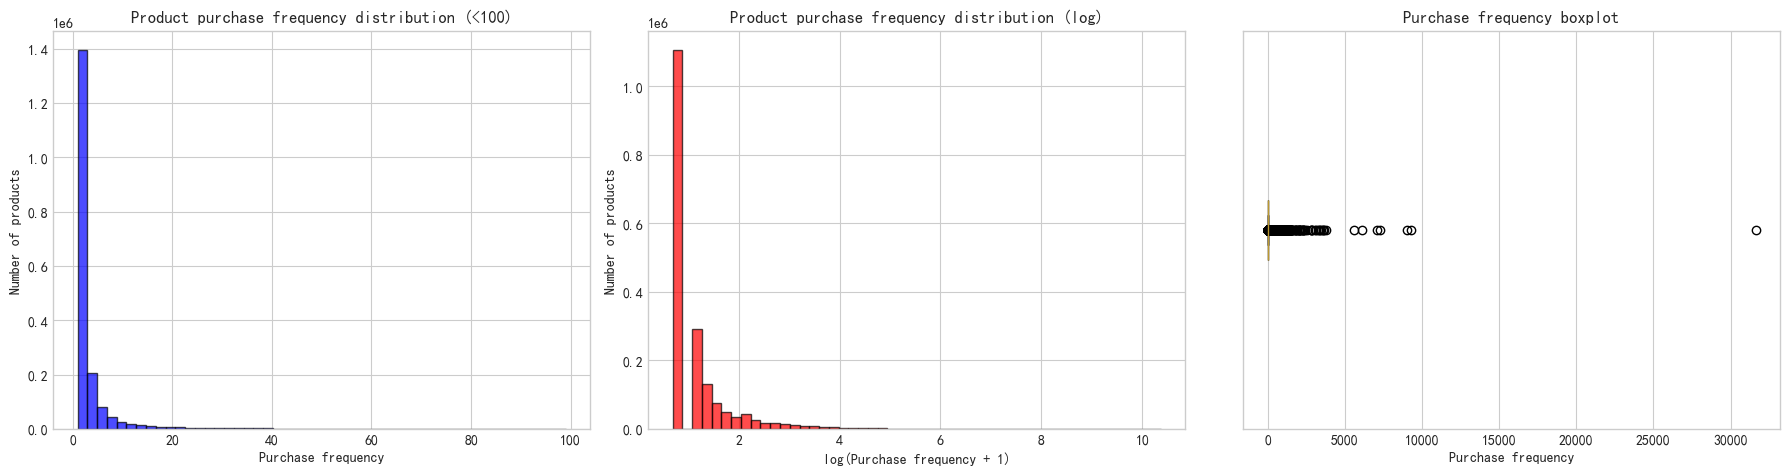


Product purchase frequency statistics:
Mean:3.77
Median:1.00
Standard deviation:32.91
Minium value:1
Maximum value:31625
Skewness:533.32
Kuroshi:471257.52

Top 20 most frequently purchased products:


item_id
7493101    31625
516873      9295
3964264     9006
7557509     7253
7482805     7078
3058048     6097
426022      5627
1872817     3770
413606      3672
6162363     3585
648691      3579
797627      3449
5421409     3405
1266501     3361
584059      3248
4163903     3115
928637      3091
564243      2910
7538392     2900
2982899     2840
dtype: int64

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_item_counts = train_df.groupby('item_id').size()

axes[0].hist(train_item_counts[train_item_counts < 100], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_title('Product purchase frequency distribution (<100)')
axes[0].set_xlabel('Purchase frequency')
axes[0].set_ylabel('Number of products')

log_item_counts = np.log1p(train_item_counts)
axes[1].hist(log_item_counts, bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1].set_title('Product purchase frequency distribution (log)')
axes[1].set_xlabel('log(Purchase frequency + 1)')
axes[1].set_ylabel('Number of products')

axes[2].boxplot(train_item_counts.values, vert=False, patch_artist=True)
axes[2].set_title('Purchase frequency boxplot')
axes[2].set_xlabel('Purchase frequency')
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

print(f'\nProduct purchase frequency statistics:')
print(f'Mean:{train_item_counts.mean():.2f}')
print(f'Median:{train_item_counts.median():.2f}')
print(f'Standard deviation:{train_item_counts.std():.2f}')
print(f'Minium value:{train_item_counts.min()}')
print(f'Maximum value:{train_item_counts.max()}')
print(f'Skewness:{train_item_counts.skew():.2f}')
print(f'Kuroshi:{train_item_counts.kurtosis():.2f}')

print('\nTop 20 most frequently purchased products:')
top_train_items = train_item_counts.nlargest(20)
display(top_train_items)

In [11]:
train_df['create_order_time'] = pd.to_datetime(train_df['create_order_time'])

train_df['order_date'] = train_df['create_order_time'].dt.date
train_df['order_hour'] = train_df['create_order_time'].dt.hour
train_df['order_dayofweek'] = train_df['create_order_time'].dt.dayofweek
train_df['order_month'] = train_df['create_order_time'].dt.month

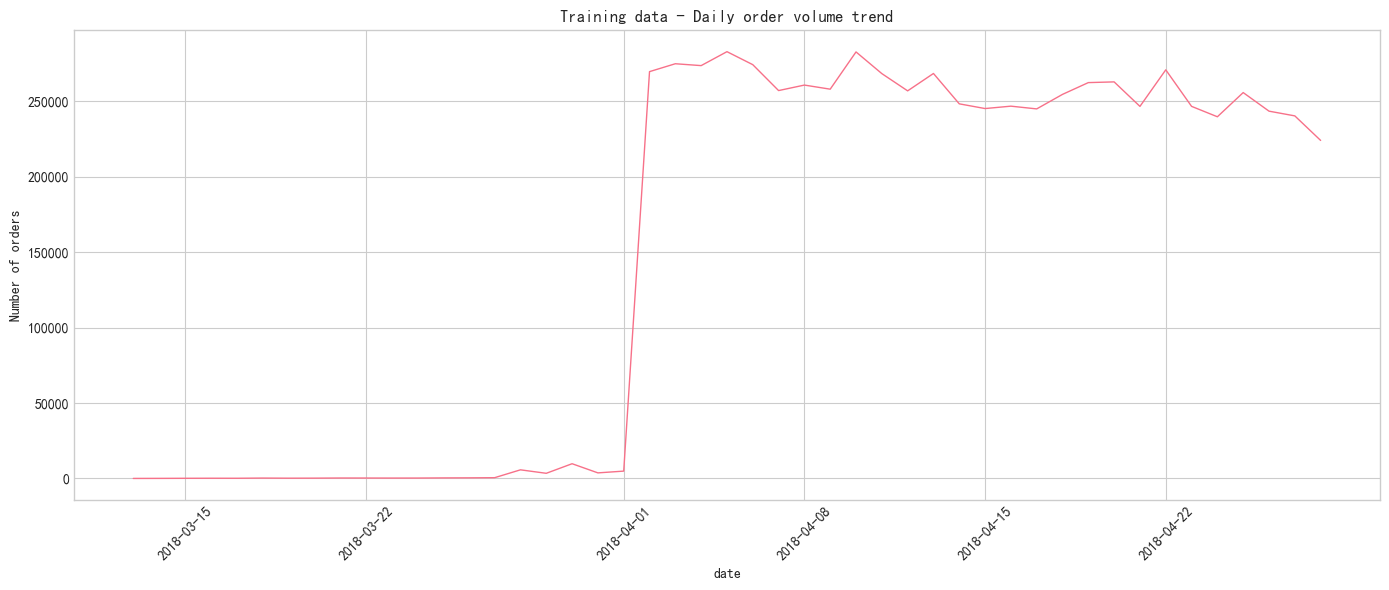

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

train_daily_orders = train_df.groupby('order_date').size()
axes.plot(train_daily_orders.index, train_daily_orders.values, linewidth=1)
axes.set_title('Training data - Daily order volume trend')
axes.set_xlabel('date')
axes.set_ylabel('Number of orders')
axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


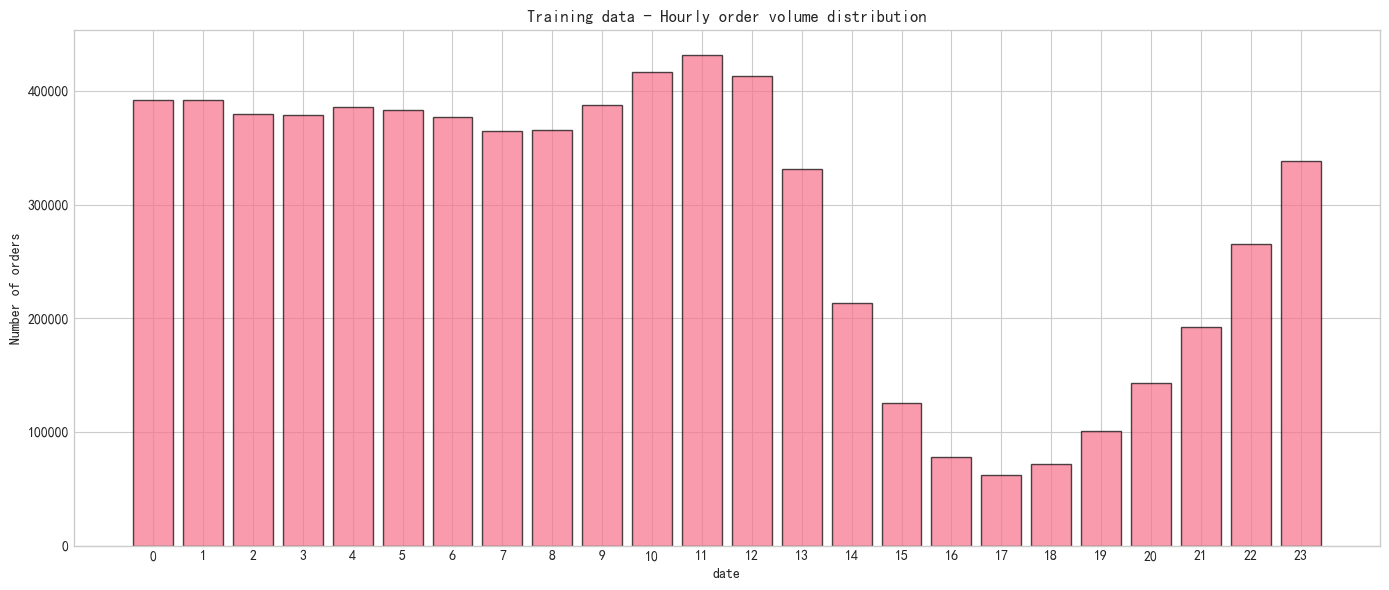

In [13]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

train_hourly = train_df.groupby('order_hour').size()
axes.bar(train_hourly.index, train_hourly.values, alpha=0.7, edgecolor='black')
axes.set_title('Training data - Hourly order volume distribution')
axes.set_xlabel('date')
axes.set_ylabel('Number of orders')
axes.set_xticks(range(24))

plt.tight_layout()
plt.show()


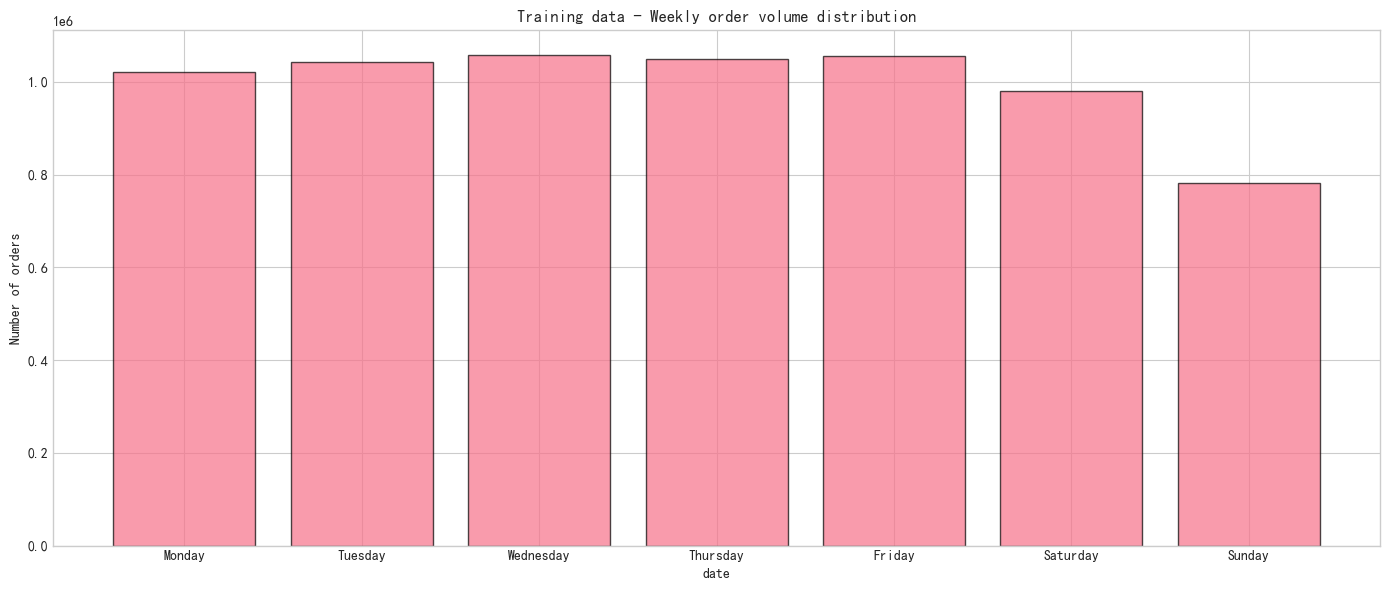

In [14]:
weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

fig, axes = plt.subplots(1, 1, figsize=(14, 6))

train_weekday = train_df.groupby('order_dayofweek').size()
axes.bar([weekday_map[i] for i in train_weekday.index], train_weekday.values, 
            alpha=0.7, edgecolor='black')
axes.set_title('Training data - Weekly order volume distribution')
axes.set_xlabel('date')
axes.set_ylabel('Number of orders')

plt.tight_layout()
plt.show()

Store Statistics
Number of unique stores: 78186


count    1.924269e+06
mean     3.368103e+04
std      1.985649e+04
min      1.000000e+00
25%      1.710700e+04
50%      3.282500e+04
75%      4.939000e+04
max      7.818600e+04
Name: store_id, dtype: float64


 Top 20 most popular stores 


store_id
1        4215
17033    1482
33081    1430
3723     1351
6087     1226
29716    1108
5939     1080
8618     1026
35919    1022
2750     1019
63790     993
48458     972
48288     946
29824     915
18907     911
59538     909
22443     896
8673      886
29456     879
29896     879
Name: count, dtype: int64

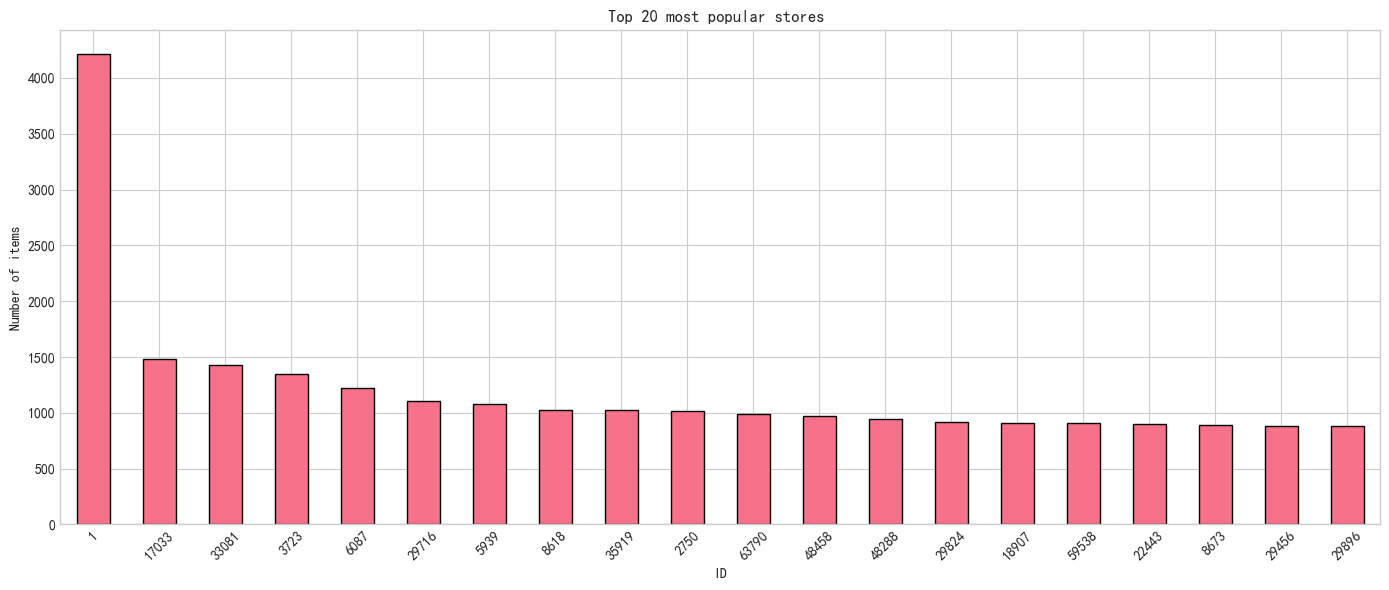

In [15]:
print('Store Statistics')
if 'store_id' in item_attr_df.columns:
    print(f'Number of unique stores: {item_attr_df["store_id"].nunique()}')
    display(item_attr_df['store_id'].describe())

    top_stores = item_attr_df['store_id'].value_counts().nlargest(20)
    print('\n Top 20 most popular stores ')
    display(top_stores)

    plt.figure(figsize=(14, 6))
    top_stores.plot(kind='bar', edgecolor='black')
    plt.title('Top 20 most popular stores ')
    plt.xlabel('ID')
    plt.ylabel('Number of items')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()